# 01 · From a GDS layout to a `Component`

Every simulation starts with geometry. gds_fdtd reads a GDS cell against a
technology and produces a **`Component`** — device polygons, a material stack,
and **auto-detected ports** — the object every engine consumes. This first
step is entirely offline (KLayout + matplotlib), no engine required.

Here we load a waveguide **crossing** shipped with the examples.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from gds_fdtd.lyprocessor import load_cell
from gds_fdtd.plotting import plot_component
from gds_fdtd.simprocessor import load_component_from_tech
from gds_fdtd.spec import SimulationSpec
from gds_fdtd.technology import Technology


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)

## 1 · Load the cell against a technology

`load_cell` opens the GDS and picks the top cell; `load_component_from_tech`
extrudes each layer's polygons to the z-heights and materials the technology
defines, and detects ports from the pin/DevRec layers. The technology is what
turns 2-D polygons into a 3-D, materialized device.

In [2]:
tech = Technology.from_yaml(_find("examples/tech.yaml"))
cell, layout = load_cell(str(_find("examples/devices.gds")), top_cell="crossing_te1550")
component = load_component_from_tech(cell=cell, tech=tech)
print(f"loaded {component.name!r}")

01:57:32 PDT WARNING: Using canonical configuration directory at                
             '/home/mustafa/.config/tidy3d'. Found legacy directory at          
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

loaded 'crossing_te1550'


## 2 · Ports — detected automatically

A crossing has four ports. Each carries its own name, µm coordinates, width,
and a snapped direction (0/90/180/270°) — everything an engine needs to launch
and collect modes.

In [3]:
for p in component.ports:
    print(f"  {p.name}: center ({p.center[0]:.2f}, {p.center[1]:.2f}, {p.center[2]:.2f}) µm, "
          f"width {p.width:.3f} µm, facing {p.direction}°")

  opt1: center (-4.80, 0.00, 0.11) µm, width 0.500 µm, facing 180°
  opt4: center (4.80, 0.00, 0.11) µm, width 0.500 µm, facing 0°
  opt2: center (0.00, 4.80, 0.11) µm, width 0.500 µm, facing 90°
  opt3: center (0.00, -4.80, 0.11) µm, width 0.500 µm, facing 270°


## 3 · Structures — role-tagged, materialized

The component is a flat list of structures, each tagged by **role** (device /
substrate / superstrate), with its GDS layer, z-extent, and resolved material.
Backgrounds (substrate/superstrate) are filled by the technology, not the GDS.

In [4]:
for s in component.structures:
    print(f"  {s.role:<11} {s.name:<10} layer {s.layer}  z {s.z_base:+.2f}…{s.z_base + s.z_span:+.2f} µm")
b = component.bounds
print(f"\nbounds: x [{b.x_min:.2f}, {b.x_max:.2f}]  y [{b.y_min:.2f}, {b.y_max:.2f}]  "
      f"z-center {b.z_center:.3f} µm")

  substrate   Substrate  layer [999, 0]  z +0.00…-2.00 µm
  superstrate Superstrate layer [999, 1]  z +0.00…+3.00 µm
  device      dev_0_0    layer [1, 0]  z +0.00…+0.22 µm

bounds: x [-4.80, 4.80]  y [-4.80, 4.80]  z-center 0.110 µm


## 4 · The geometry view

The standard picture: device polygons (per layer), the detected ports
(arrows + width ticks), the `devrec` bounds, and — given a `SimulationSpec` —
the FDTD region and the port-extension stubs the solvers push through the PML.
Each simulation notebook opens with this geometry view.

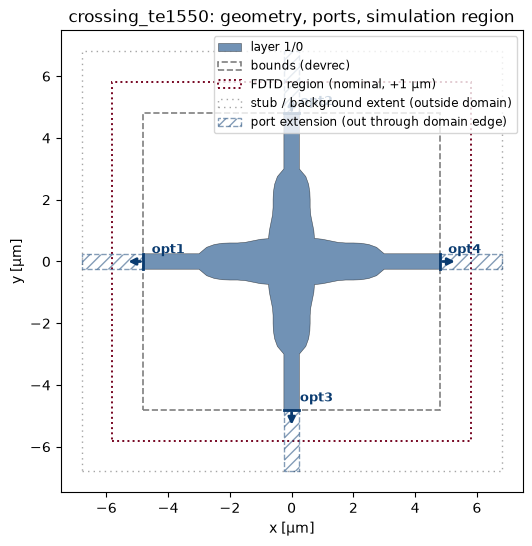

In [5]:
plot_component(component, spec=SimulationSpec(buffer=1.0))
plt.show()

## 5 · The same component in 3D

`show_3d` renders the extruded stack interactively — drag to orbit, scroll
to zoom, click any object for its name, material, and z-extent; the legend
toggles layers, ports, and the translucent substrate/superstrate. It works
in the notebook and in this documentation page alike (the static fallback
for JavaScript-free contexts is `viewer3d.render_static`).

In [6]:
from gds_fdtd.viewer3d import show_3d  # noqa: E402

show_3d(component, height=420)

/home/mustafa/miniconda3/envs/gds_fdtd/lib/python3.12/site-packages/IPython/core/display.py:446: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [7]:
del layout  # release the KLayout objects

## Recap & next

One `Component` — geometry + materials + ports — is all any engine needs, and
it came from a plain GDS file plus a technology. The rest of the toolbox works
the same regardless of the source.

- **`02_technology`** — the material side of that technology.
- **`03_first_simulation`** — put this Component through an FDTD engine.
- **`08_frontends`** — the same Component from gdsfactory / SiEPIC / raw GDS.